In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.datasets import make_circles


In [9]:
X,y=make_circles(n_samples=200, noise=0.1,random_state=1)


<Axes: >

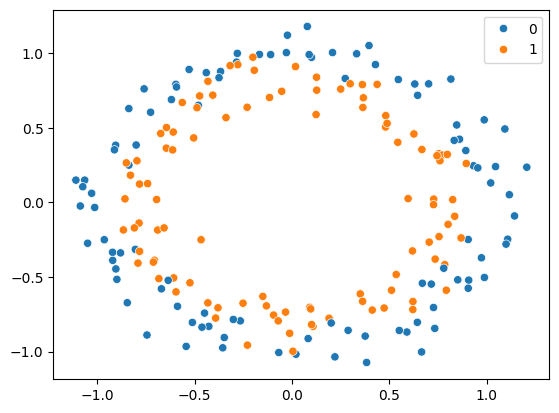

In [11]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [12]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y, test_size=0.2,random_state=42)

In [21]:
model=Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [23]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [28]:
callback=EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [29]:
history=model.fit(X_train,Y_train, validation_data=(X_test,Y_test), epochs=3000, callbacks=callback)

Epoch 1/3000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.4812 - loss: 0.6926 - val_accuracy: 0.3750 - val_loss: 0.6971
Epoch 2/3000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5250 - loss: 0.6895 - val_accuracy: 0.4250 - val_loss: 0.7000
Epoch 3/3000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5437 - loss: 0.6871 - val_accuracy: 0.4500 - val_loss: 0.7017
Epoch 4/3000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5500 - loss: 0.6850 - val_accuracy: 0.4500 - val_loss: 0.7023
Epoch 5/3000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5437 - loss: 0.6841 - val_accuracy: 0.4500 - val_loss: 0.7037
Epoch 6/3000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5188 - loss: 0.6828 - val_accuracy: 0.4500 - val_loss: 0.7038
Epoch 7/3000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5188 - loss: 0.6822 - val_accuracy: 0.4500 - val_loss: 0.7041
Epoch 8/3000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5125 - loss: 0.6810 - val_accuracy: 0.4500 - v

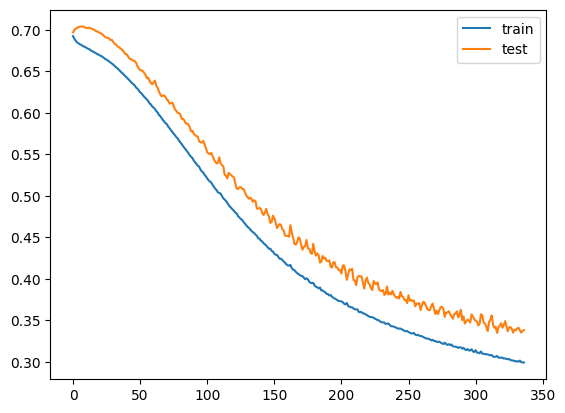

In [32]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


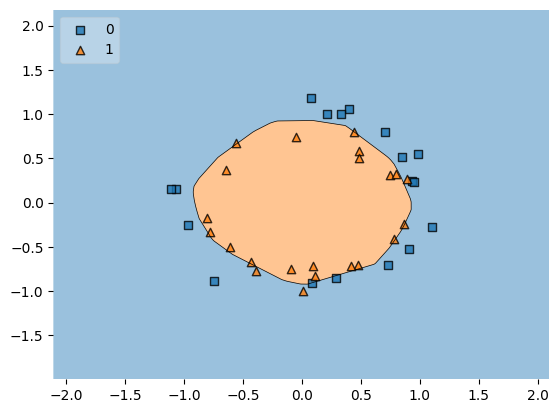

In [34]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_test,Y_test.ravel(),clf=model,legend=2)
plt.show()